In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns

In [2]:
data=nc.Dataset('/home/dell/iHESPdata/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.PSL.h.0375-07.nc')

lont = data.variables['lon'][:]
latt = data.variables['lat'][:384]
[xx, yy] = np.meshgrid(lont, latt)

In [3]:
data.variables['PSL']

<class 'netCDF4._netCDF4.Variable'>
float32 PSL(time, lat, lon)
    units: Pa
    long_name: Sea level pressure
    cell_methods: time: mean
    cell_measures: area: area
unlimited dimensions: time
current shape = (1, 768, 1152)
filling on, default _FillValue of 9.969209968386869e+36 used

In [4]:
xx.shape

(384, 1152)

In [5]:
# 250-338
# 338-500
lont[:65]

masked_array(data=[ 0.    ,  0.3125,  0.625 ,  0.9375,  1.25  ,  1.5625,
                    1.875 ,  2.1875,  2.5   ,  2.8125,  3.125 ,  3.4375,
                    3.75  ,  4.0625,  4.375 ,  4.6875,  5.    ,  5.3125,
                    5.625 ,  5.9375,  6.25  ,  6.5625,  6.875 ,  7.1875,
                    7.5   ,  7.8125,  8.125 ,  8.4375,  8.75  ,  9.0625,
                    9.375 ,  9.6875, 10.    , 10.3125, 10.625 , 10.9375,
                   11.25  , 11.5625, 11.875 , 12.1875, 12.5   , 12.8125,
                   13.125 , 13.4375, 13.75  , 14.0625, 14.375 , 14.6875,
                   15.    , 15.3125, 15.625 , 15.9375, 16.25  , 16.5625,
                   16.875 , 17.1875, 17.5   , 17.8125, 18.125 , 18.4375,
                   18.75  , 19.0625, 19.375 , 19.6875, 20.    ],
             mask=False,
       fill_value=1e+20)

In [6]:
latt[85:115]

masked_array(data=[-70.05215454, -69.81747437, -69.58279419, -69.34810638,
                   -69.11342621, -68.87874603, -68.64406586, -68.40938568,
                   -68.17470551, -67.94002533, -67.70534515, -67.47066498,
                   -67.2359848 , -67.00130463, -66.76662445, -66.53194427,
                   -66.2972641 , -66.06257629, -65.82789612, -65.59321594,
                   -65.35853577, -65.12385559, -64.88917542, -64.65449524,
                   -64.41981506, -64.18513489, -63.95045471, -63.71577454,
                   -63.48109436, -63.24641418],
             mask=False,
       fill_value=1e+20)

In [7]:
plotvar2 = np.load('/home/dell/iHESPdata/PSLtime70rrALL.npy')
plotvar1 = np.load('/home/dell/iHESPdata/PSLtime70rrplusALL.npy')
p5 = (plotvar2+plotvar1)/2
pla3 = p5.reshape(250,12)
p55 = np.nanmean(pla3,axis=1)

In [8]:
arr = p55/100
window_size = 5

i = 0
# Initialize an empty list to store moving averages
moving_averages5 = []

# Loop through the array t o
#consider every window of size 3
while i < len(arr) - window_size + 1:

    # Calculate the average of current window
    window_average = round(np.sum(arr[
      i:i+window_size]) / window_size, 2)
    
    # Store the average of current
    # window in moving average list
    moving_averages5.append(window_average)
    
    # Shift window to right by one position
    i += 1

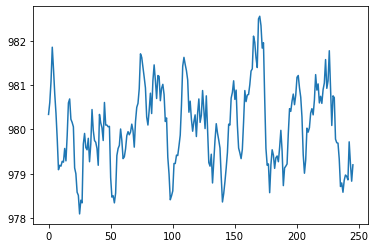

In [9]:
plt.plot( moving_averages5)

In [10]:
WSPsmall = np.load('/home/dell/iHESPplot/iceplot/smallMRP.npy')
WSPbigger = np.load('/home/dell/iHESPplot/iceplot/smallWSP.npy')

In [11]:
openocean = np.load('/home/dell/iHESPplot/SWMT/openoceandeep176runing.npy')
openoceantime = np.load('/home/dell/iHESPplot/SWMT/openoceandeeptime176runing.npy')

findfont: Font family ['Cambria'] not found. Falling back to DejaVu Sans.


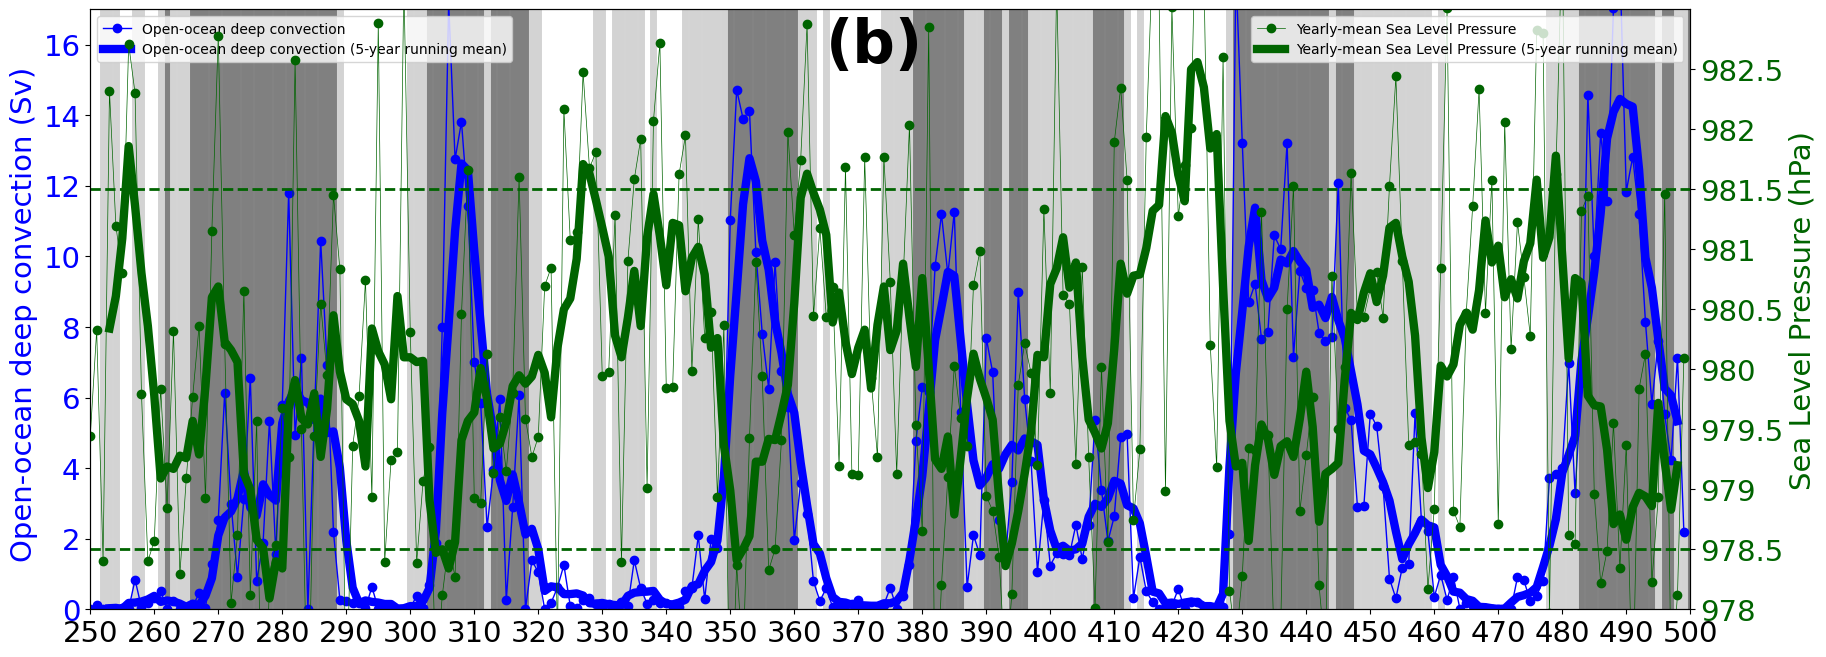

In [12]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = {'fontname':'Cambria', 'size':'21'}
################################################################
################################################################
t = np.arange(3,249,1)
ax1 = fig.add_axes([0.1, 0.9, 0.8, 0.3],
                   xticklabels=[])

t = np.arange(3,249,1)
plt.vlines(WSPbigger, 0, 20, linestyles="solid", colors="grey" ,linewidth=5)
plt.vlines(WSPsmall, 0, 20, linestyles="solid", colors="lightgrey" ,linewidth=5)
ax1.plot(openoceantime,color='blue',marker='o',linewidth=1,label='Open-ocean deep convection')

ax1.plot(t,openocean,color='blue',linewidth=6,label='Open-ocean deep convection (5-year running mean)')
plt.legend(loc='upper left')
plt.yticks(np.arange(0,20,2), ['0','2','4','6','8','10','12','14', '16', '18'],**my_font,color='blue')
plt.ylabel('Open-ocean deep convection (Sv) ',**my_font,color='blue')
#plt.title('Weddell DSW overflow across 1000m isodepth ($\sigma$$_1$>32.58)',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
ax1.set(ylim=(0, 17),xlim=(0, 250))

ax2 = ax1.twinx()

ax2.plot(p55/100,color='darkgreen',marker='o',linewidth=0.5,label='Yearly-mean Sea Level Pressure ')
ax2.plot(t,moving_averages5,color='darkgreen',linewidth=6,label='Yearly-mean Sea Level Pressure (5-year running mean)')

#ax1.plot(p5,color='yellow',marker='o',linewidth=3)
#ax1.plot(p5,color='red',marker='o',linewidth=1)
plt.legend(loc='upper right')
plt.hlines(981.5, 0, 250, linestyles="dashed", colors="darkgreen" ,linewidth=2)
plt.hlines(978.5, 0, 250, linestyles="dashed", colors="darkgreen" ,linewidth=2)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
plt.yticks(np.arange(978,983,0.5), ['978','978.5','979','979.5','980','980.5','981','981.5','982','982.5'],**my_font,color='darkgreen')
plt.ylabel('Sea Level Pressure (hPa)',**my_font,color='darkgreen')

ax2.set(ylim=(978, 983),xlim=(0, 250))
ax1.text(115, 15.5, '(b)',size=43, weight='bold',color='black')
plt.savefig("Fig.SS4b.png",bbox_inches='tight')


In [13]:
pwd

'/home/dell/iHESPplot/Paper3'